**Multi-Armed Bandit**

This file contains all the MAB code (assginment 3) for the report 

## Define all the MAB algorithms

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Bandit Environment
class BanditEnvironment:
    def __init__(self, num_arms, reward_means):
        self.num_arms = num_arms
        self.reward_means = reward_means

    def pull_arm(self, arm):
        return np.random.binomial(1, self.reward_means[arm])  # Bernoulli rewards

# ==========================
# Fixed Exploration Then Exploitation 
# ==========================
class FixedExplorationThenGreedy:
    def __init__(self, num_arms, exploration_steps):
        self.num_arms = num_arms
        self.exploration_steps = exploration_steps
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self):
        if self.t <= self.exploration_steps:  # Exploration phase
            return np.random.randint(self.num_arms)
        else:  # Exploitation phase
            return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]  
        self.t += 1

# ==========================
# Epsilon-Greedy Algorithm 
# ==========================
class EpsilonGreedy:
    def __init__(self, num_arms, epsilon):
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:  # Exploration
            return np.random.randint(self.num_arms)
        else:  # Exploitation
            return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

# ==========================
# Epsilon-Greedy with Decaying Exploration 
# ==========================
class EpsilonGreedyDecaying:
    def __init__(self, num_arms, epsilon_schedule):
        self.num_arms = num_arms
        self.epsilon_schedule = epsilon_schedule  # Function for epsilon_t
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self):
        epsilon_t = self.epsilon_schedule(self.t)
        if np.random.rand() < epsilon_t:  # Explore
            return np.random.randint(self.num_arms)
        else:  # Exploit
            return int(np.argmax(self.values))

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm] 
        self.t += 1

# ==========================
# UCB Algorithm 
# ==========================
class UCB:
    def __init__(self, num_arms, c):
        self.num_arms = num_arms
        self.c = c
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self): 
        # Ensure every arm is tried at least once
        for arm in range(self.num_arms):
            if self.counts[arm] == 0:
                return arm 

        ucb_values = self.values + np.sqrt(np.log(1 / self.c) / (2 * self.counts)) 
        return np.argmax(ucb_values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm] 
        self.t += 1

# ==========================
# Thompson Sampling Algorithm 
# ==========================
class ThompsonSampling: 
    def __init__(self, num_arms, alpha_prior = 1, beta_prior = 1):
        self.num_arms = num_arms
        # modified to take care of the prior distrituion affectively
        self.successes = np.ones(num_arms) * alpha_prior
        self.failures = np.ones(num_arms) * beta_prior


    def select_arm(self):
        samples = [np.random.beta(self.successes[i], self.failures[i]) for i in range(self.num_arms)]

        return np.argmax(samples)

    def update(self, arm, reward):
        if reward == 1:
            self.successes[arm] += 1
        else:
            self.failures[arm] += 1

# ==========================
# Experiment Runner
# ==========================
def run_experiment(bandit_class, bandit_params, env, num_steps):
    bandit = bandit_class(**bandit_params)
    regrets = []
    optimal_reward = max(env.reward_means)

    for t in range(num_steps):
        arm = bandit.select_arm()
        reward = env.pull_arm(arm)
        bandit.update(arm, reward)
        regret = optimal_reward - reward
        regrets.append(regret)

    return np.cumsum(regrets)

## Run all the relevant experiments

### • initialize the environment: use linearly spaces rewards

In [34]:
# set up the environmnet
num_arms = 10
reward_means = np.linspace(0, 1, num_arms) 
env = BanditEnvironment(num_arms, reward_means)
num_steps = 300

### • create a function that takes the algorithm and produces the expected regret w.r.t time

In [ ]:
def expected_regret(alg, parameterization, env, num_steps, iter = None):
    """ 
    Input:
        alg: algorithm
        parameteriztion: dictionary with paramters of the algorithm
        env: bandit environment
        num_steps: number of steps
    """
    if iter is not None:
        n_iter = iter
    else:
        n_iter = 10000 # number of runs to take the average over
    # store all the regret
    alg_regret = np.zeros((n_iter,num_steps))
    
    for i in range(n_iter):
        alg_regret[i,:] = run_experiment(alg, parameterization, env, num_steps)
    return np.mean(alg_regret,0)

### • Plot the expected regret w.r.t time for the different MAB algorithms for similar parameter values as provided i the assignment 

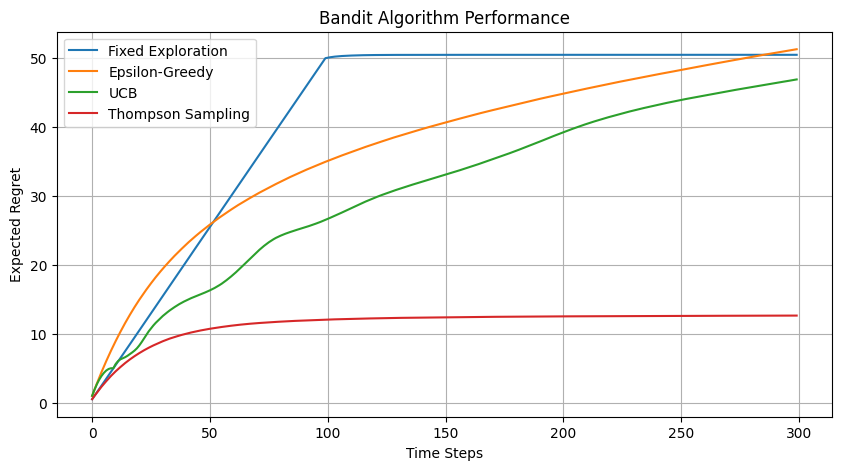

In [ ]:
def plot(e_s = 100, eps = 0.1, c = 0.0001, prior = 1, eps_schedule = None, name = None):
    """ 
        plot the extected regret over time

        Input:
        e_s: exploration steps for fixed exploration then exploitation
        eps: espilon for epsilon greedy
        c: UCB parameter
        prior: prior distribution values for thompson
    """
    # Plot setup
    plt.figure(figsize = (10,5))

    # Run and plot Fixed Exploration Then Exploitation
    fixed_exploration_regret = expected_regret(FixedExplorationThenGreedy, {'num_arms': num_arms, 'exploration_steps': e_s}, env, num_steps)
    plt.plot(fixed_exploration_regret, label='Fixed Exploration')

    # Run and plot ε-Greedy
    epsilon_greedy_regret = expected_regret(EpsilonGreedy, {'num_arms': num_arms, 'epsilon': eps}, env, num_steps)
    plt.plot(epsilon_greedy_regret, label='Epsilon-Greedy')

    # Run and plot UCB
    # Note: we define 'c' as in the lecture notes and therefore it takes values between 0 and 1
    ucb_regret = expected_regret(UCB, {'num_arms': num_arms, 'c': c}, env, num_steps)
    plt.plot(ucb_regret, label='UCB')

    # Run and plot Thompson Sampling
    thompson_regret = expected_regret(ThompsonSampling, {'num_arms': num_arms,'alpha_prior' : prior,'beta_prior' : prior}, env, num_steps)
    plt.plot(thompson_regret, label='Thompson Sampling')

    # plot the epsilon greedy with epsilon schedule
    if eps_schedule is not None:
            decaying_epsilon_greedy_regret = expected_regret(EpsilonGreedyDecaying, {'num_arms': num_arms, 'epsilon_schedule': eps_schedule}, env, num_steps)
            plt.plot(decaying_epsilon_greedy_regret, label = f'Epsilon Schedule: {name}')

    plt.xlabel("Time Steps")
    plt.ylabel("Expected Regret")
    plt.legend()
    plt.title("Bandit Algorithm Performance")
    plt.grid(True)
    plt.show()

plot()

### • plot the epsilon greedy with different epsilon schedules

##### 1. define the epsilon schedules

In [5]:
# Epsilon schedules
schedules = {
    '1/t': lambda t: 1 / t,
    '1/sqrt(t)': lambda t: 1 / np.sqrt(t),
    'log(t)/t': lambda t: np.log(t) / t
}

##### 2. plot the epsilon schedules

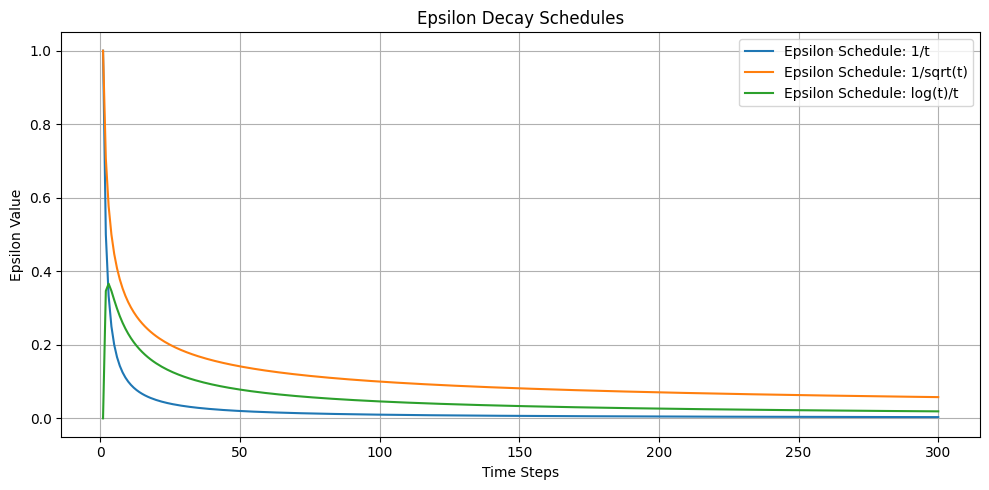

In [6]:
t_values = np.arange(1, num_steps + 1)

# do the plotting 
plt.figure(figsize = (10, 5))

for name, schedule in schedules.items(): # loop through each schedule
    epsilon_values = [schedule(t) for t in t_values]
    plt.plot(t_values, epsilon_values, label = f'Epsilon Schedule: {name}')

plt.xlabel("Time Steps")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay Schedules")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### 2. plot the expected regret of the epsilon-greedy over these epsilon schedules

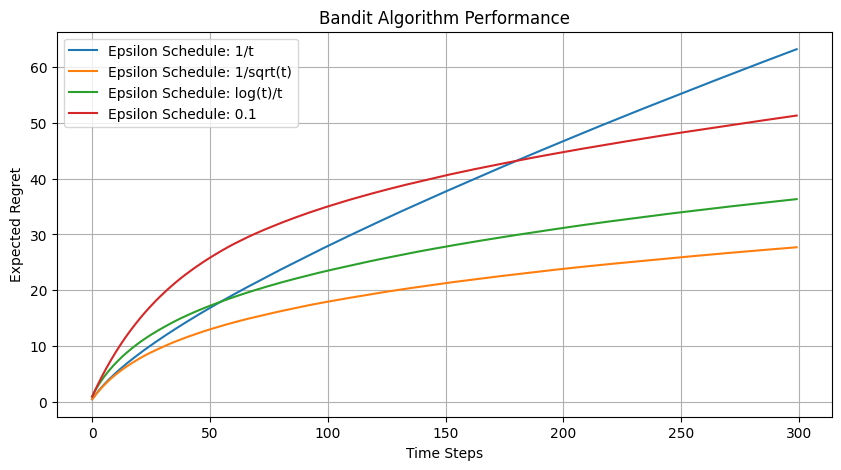

In [7]:
# Epsilon schedules with the addition of the constant that was used before
schedules = {
    '1/t': lambda t: 1 / t,
    '1/sqrt(t)': lambda t: 1 / np.sqrt(t),
    'log(t)/t': lambda t: np.log(t) / t,
    '0.1': 0.1
}

# Plot setup
plt.figure(figsize = (10,5))

# for 
for name, schedule in schedules.items(): # loop through each schedule
    if schedule == 0.1: # check for the constant schedule
        decaying_epsilon_greedy_regret = expected_regret(EpsilonGreedy, {'num_arms': num_arms, 'epsilon': 0.1}, env, num_steps)
    else:
        decaying_epsilon_greedy_regret = expected_regret(EpsilonGreedyDecaying, {'num_arms': num_arms, 'epsilon_schedule': schedule}, env, num_steps)
    plt.plot(decaying_epsilon_greedy_regret, label = f'Epsilon Schedule: {name}')

# decaying_epsilon_greedy_regret = run_experiment(EpsilonGreedyDecaying, {'num_arms': num_arms, 'epsilon_schedule': epsilon_schedule}, env, num_steps)
# plt.plot(decaying_epsilon_greedy_regret, label='Decaying Epsilon-Greedy')

plt.xlabel("Time Steps")
plt.ylabel("Expected Regret")
plt.legend()
plt.title("Bandit Algorithm Performance")
plt.grid(True)
plt.show()

### • Plot the expected regret when the reward means are uniformly distributed between 0.7 and 0.8

##### 1. plot the expected regret

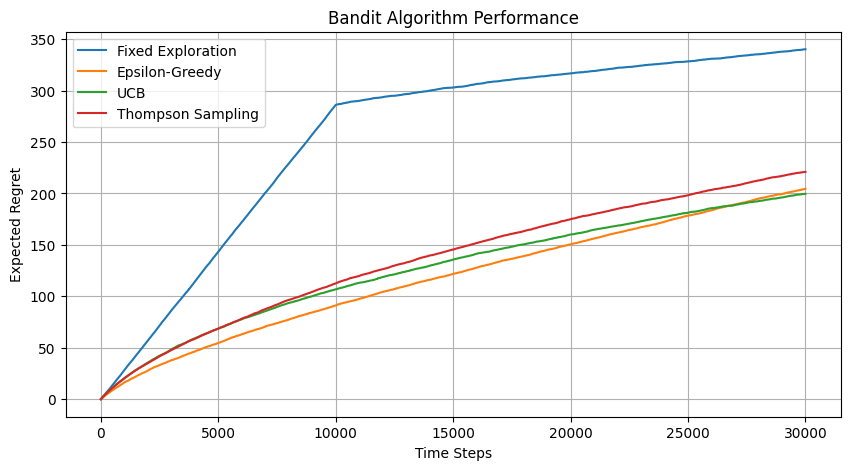

In [64]:
# plot it for two differnt number of steps, i.e the same as before on one much higher
num_arms = 10
n_s = 30000 # number of steps
reward_means = np.random.uniform(0.7, 0.8, num_arms)
env = BanditEnvironment(num_arms, reward_means)

plot(e_s = 10000, c = 0.05)
 


### • plot the expected regret when the reward means are linearly spaced but there are 3000 arms

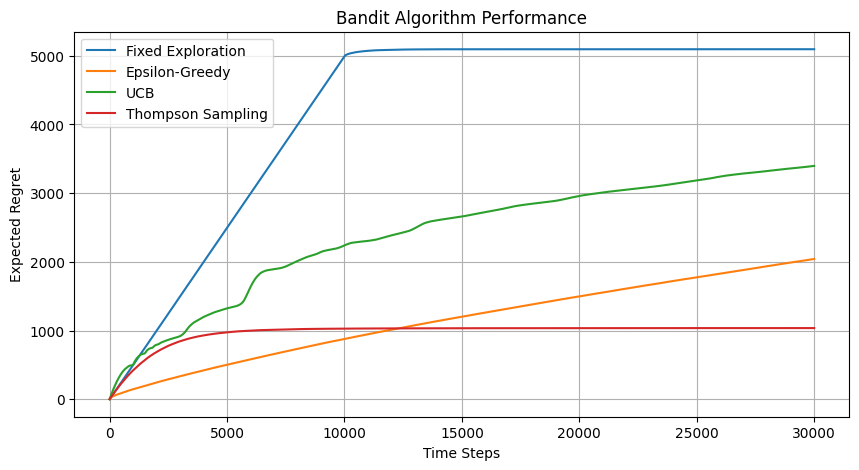

In [61]:
# set up the environmnet
num_arms = 1000
reward_means = np.linspace(0, 1, num_arms) 
env = BanditEnvironment(num_arms, reward_means)
num_steps = 30000
# Plot setup

plot(e_s = 10000, c = 0.05)

### • Perform hyperparameter tuning for the case when number of arms = 10 and reward means are linearly spaced

Note: please remeber we are performing hyperparemeter tuning in on a very particular environmemnt i.e in real life you would have to train and then test the model, this is very important not to exclude in the report

##### 1. initialize the envirnoment

In [26]:
# set up the environmnet
num_arms = 10
reward_means = np.linspace(0, 1, num_arms) 
env = BanditEnvironment(num_arms, reward_means)
num_steps = 300


# set up the parameter space

explore_steps = np.arange(20, 100, 5) # fixed exploration then greedy
epsilon = np.linspace(0,1,20) # epsilon greedy
c = np.linspace(0.001,1,20) # UCB
prior = np.linspace(0.5,3,10) # thompson (assuming both parameter to be the same)

##### 2. perform hyperparamter tuning

In [27]:
index_explore_steps = 0
index_epsilon = 0
index_c = 0
index_prior = 0


min = 10000 # dummy max bound
# note we set the number of iterations to 500 as it would be too computationlly heavy otherwise
for i in range(len(explore_steps)):
    value = expected_regret(FixedExplorationThenGreedy, {'num_arms': num_arms, 'exploration_steps': explore_steps[i]}, env, num_steps, iter = 100)[-1]
    if value < min:
        min = value
        index_explore_steps = explore_steps[i]
print('FixedExplorationThenGreedy hyperparameter tunin is done')
min = 10000
for i in range(len(epsilon)):
    value = expected_regret(EpsilonGreedy, {'num_arms': num_arms, 'epsilon': epsilon[i]}, env, num_steps, iter = 100)[-1]
    if value < min:
        min = value
        index_epsilon = epsilon[i]
print('EpsilonGreedy hyperparameter tuning is done')
min = 10000
for i in range(len(c)):
    value = expected_regret(UCB, {'num_arms': num_arms, 'c': c[i]}, env, num_steps, iter = 100)[-1]
    if value < min:
        min = value
        index_c = c[i]
print('UCB hyperparameter tuning is done')
min = 10000
for i in range(len(prior)):
    value = expected_regret(ThompsonSampling, {'num_arms': num_arms,'alpha_prior' : prior,'beta_prior' : prior[i]}, env, num_steps)[-1]
    if value < min:
        min = value
        index_prior = prior[i]



FixedExplorationThenGreedy hyperparameter tunin is done
EpsilonGreedy hyperparameter tuning is done
UCB hyperparameter tuning is done


##### 3. plot the resulting expected regrets

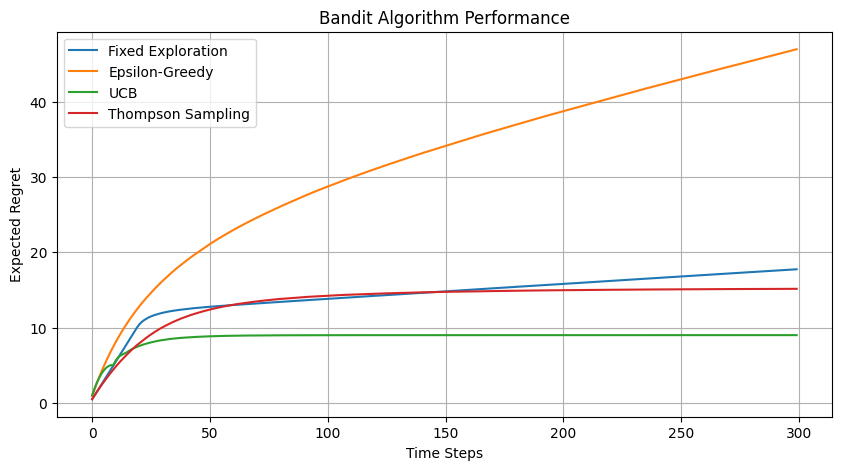

In [28]:
plot(index_explore_steps, index_epsilon, index_c, index_prior)